# DeliveryETA — Data Loading and Cleaning

This notebook analyzes and cleans the delivery dataset.

The cleaning operations include:

- inspecting the dataset;
- removing parasite text;
- converting data types;
- detecting missing values;
- detecting invalid GPS coordinates;
- checking outliers;
- removing duplicates;
- applying the reusable cleaning function;
- saving the cleaned dataset.

In [10]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_cleaning import clean_data

sns.set_theme(style="whitegrid")

raw_data_path = (
    project_root
    / "data"
    / "raw"
    / "food_delivery.csv"
)

clean_data_path = (
    project_root
    / "data"
    / "processed"
    / "delivery_clean.csv"
)

print("Raw dataset:", raw_data_path)
print("File exists:", raw_data_path.exists())

Raw dataset: /home/bsar/Desktop/delivery-eta/data/raw/food_delivery.csv
File exists: True


## 1. Load the dataset

The original CSV file is loaded without modifying it. The cleaning operations will be applied to a separate copy.

In [11]:
raw_dataframe = pd.read_csv(raw_data_path)

print(f"Rows: {raw_dataframe.shape[0]}")
print(f"Columns: {raw_dataframe.shape[1]}")

display(raw_dataframe.head())

Rows: 45593
Columns: 20


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [12]:
print("Column names:")

for column in raw_dataframe.columns:
    print(repr(column)) #repr() helps reveal hidden spaces around column names.

raw_dataframe.info()

Column names:
'ID'
'Delivery_person_ID'
'Delivery_person_Age'
'Delivery_person_Ratings'
'Restaurant_latitude'
'Restaurant_longitude'
'Delivery_location_latitude'
'Delivery_location_longitude'
'Order_Date'
'Time_Orderd'
'Time_Order_picked'
'Weatherconditions'
'Road_traffic_density'
'Vehicle_condition'
'Type_of_order'
'Type_of_vehicle'
'multiple_deliveries'
'Festival'
'City'
'Time_taken(min)'
<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  str    
 3   Delivery_person_Ratings      45593 non-null  str    
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-

In [13]:
kept_columns = {
    "Restaurant_latitude": "numeric GPS",
    "Restaurant_longitude": "numeric GPS",
    "Delivery_location_latitude": "numeric GPS",
    "Delivery_location_longitude": "numeric GPS",
    "Time_Orderd": "time",
    "Time_Order_picked": "time",
    "Weatherconditions": "categorical",
    "Road_traffic_density": "categorical",
    "Type_of_vehicle": "categorical",
    "City": "categorical",
    "Time_taken(min)": "target",
}

column_roles = pd.DataFrame(
    {
        "column": raw_dataframe.columns,
        "data_type": raw_dataframe.dtypes.astype(str).values,
        "role": [
            kept_columns.get(column, "removed column")
            for column in raw_dataframe.columns
        ]
    }
)

column_roles

,column,data_type,role
0,ID,str,removed column
1,Delivery_person_ID,str,removed column
2,Delivery_person_Age,str,removed column
3,Delivery_person_Ratings,str,removed column
4,Restaurant_latitude,float64,numeric GPS
5,Restaurant_longitude,float64,numeric GPS
6,Delivery_location_latitude,float64,numeric GPS
7,Delivery_location_longitude,float64,numeric GPS
8,Order_Date,str,removed column
9,Time_Orderd,str,time


In [14]:
raw_dataframe.describe(include="all")

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
count,45593,45593,45593,45593,45593.000000,45593.000000,45593.000000,45593.000000,45593,45593,45593,45593,45593,45593.000000,45593,45593,45593,45593,45593,45593
unique,45593,1320,23,29,NaN,NaN,NaN,NaN,44,177,193,7,5,NaN,4,4,5,3,4,45
top,0x4607,JAPRES11DEL02,35,4.8,NaN,NaN,NaN,NaN,15-03-2022,NaN,21:30:00,conditions Fog,Low,NaN,Snack,motorcycle,1,No,Metropolitian,(min) 26
freq,1,67,2262,7148,NaN,NaN,NaN,NaN,1192,1731,496,7654,15477,NaN,11533,26435,28159,44469,34093,2123
mean,NaN,NaN,NaN,NaN,17.017729,70.231332,17.465186,70.845702,NaN,NaN,NaN,NaN,NaN,1.023359,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,8.185109,22.883647,7.335122,21.118812,NaN,NaN,NaN,NaN,NaN,0.839065,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,-30.905562,-88.366217,0.010000,0.010000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,12.933284,73.170000,12.988453,73.280000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,18.546947,75.898497,18.633934,76.002574,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,22.728163,78.044095,22.785049,78.107044,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Inspect parasite text

The dataset contains values with extra text:

- `"(min) 24"` must become `24`.
- `"conditions Sunny"` must become `"Sunny"`.

Spaces around categorical values must also be removed.

In [15]:
print("Delivery_time examples:")

display(
    raw_dataframe[
        "Time_taken(min)"
    ].head(10)
)

print("\nWeather values:")

display(
    raw_dataframe[
        "Weatherconditions"
    ].value_counts(dropna=False)
)

Delivery_time examples:


0    (min) 24
1    (min) 33
2    (min) 26
3    (min) 21
4    (min) 30
5    (min) 26
6    (min) 40
7    (min) 32
8    (min) 34
9    (min) 46
Name: Time_taken(min), dtype: str


Weather values:


Weatherconditions
conditions Fog           7654
conditions Stormy        7586
conditions Cloudy        7536
conditions Sandstorms    7495
conditions Windy         7422
conditions Sunny         7284
conditions NaN            616
Name: count, dtype: int64

In [27]:
# Inspect categorical columns
categorical_columns = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_vehicle",
    "City",
]

for column in categorical_columns:
    print(f"\n--- {column}---")

    print(
        raw_dataframe[column]
        .astype("string")
        .str.strip()
        .value_counts(dropna=False)
    )


--- Weatherconditions---
Weatherconditions
conditions Fog           7654
conditions Stormy        7586
conditions Cloudy        7536
conditions Sandstorms    7495
conditions Windy         7422
conditions Sunny         7284
conditions NaN            616
Name: count, dtype: int64[pyarrow]

--- Road_traffic_density---
Road_traffic_density
Low       15477
Jam       14143
Medium    10947
High       4425
NaN         601
Name: count, dtype: int64[pyarrow]

--- Type_of_vehicle---
Type_of_vehicle
motorcycle          26435
scooter             15276
electric_scooter     3814
bicycle                68
Name: count, dtype: int64[pyarrow]

--- City---
City
Metropolitian    34093
Urban            10136
NaN               1200
Semi-Urban         164
Name: count, dtype: int64[pyarrow]


### Parasite-text treatment

The cleaning function:

- removes spaces around categorical values;
- extracts the numerical value from `Time_taken(min)`;
- removes the word `conditions` from `Weatherconditions`;
- converts textual missing markers such as `"NaN"` into real missing values.

In [30]:
missing_count = raw_dataframe.isna().sum()

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percentage": (
        missing_count / len(raw_dataframe) * 100
    ).round(2)
}).sort_values(
    by="missing_count",
    ascending=False
)

missing_report

,missing_count,missing_percentage
ID,0,0.0
Delivery_person_ID,0,0.0
Delivery_person_Age,0,0.0
Delivery_person_Ratings,0,0.0
Restaurant_latitude,0,0.0
Restaurant_longitude,0,0.0
Delivery_location_latitude,0,0.0
Delivery_location_longitude,0,0.0
Order_Date,0,0.0
Time_Orderd,0,0.0


In [18]:
textual_missing_report = {}

missing_markers = [
    "NaN",
    "nan",
    "None",
    "NULL",
    "",
]

for column in raw_dataframe.columns:
    values = (
        raw_dataframe[column]
        .astype("string")
        .str.strip()
    )

    textual_missing_report[column] = (
        values.isin(missing_markers).sum()
    )

textual_missing_report = pd.Series(
    textual_missing_report,
    name="textual_missing_count"
).sort_values(ascending=False)

textual_missing_report

Delivery_person_Ratings        1908
Delivery_person_Age            1854
Time_Orderd                    1731
City                           1200
multiple_deliveries             993
Road_traffic_density            601
Festival                        228
Delivery_person_ID                0
ID                                0
Restaurant_latitude               0
Delivery_location_latitude        0
Restaurant_longitude              0
Weatherconditions                 0
Time_Order_picked                 0
Order_Date                        0
Delivery_location_longitude       0
Type_of_vehicle                   0
Type_of_order                     0
Vehicle_condition                 0
Time_taken(min)                   0
Name: textual_missing_count, dtype: int64

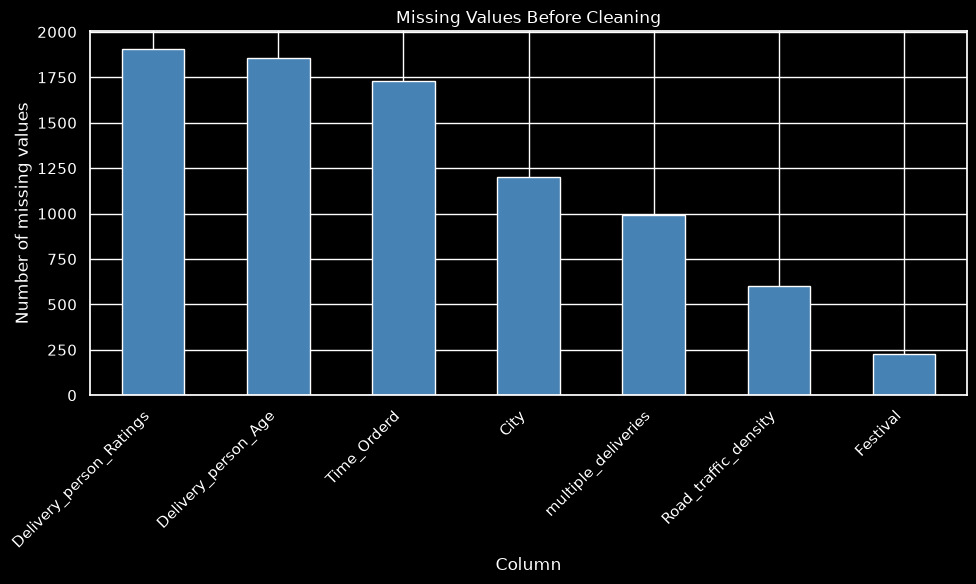

In [ ]:
combined_missing = (
    raw_dataframe.isna().sum()
    + textual_missing_report
)

combined_missing = combined_missing[
    combined_missing > 0
].sort_values(ascending=False)

plt.style.use("dark_background")

plt.figure(figsize=(10, 6))

combined_missing.plot(
    kind="bar",  
    color="steelblue"
)

plt.title(
    "Missing Values Before Cleaning",
    color="white"
)

plt.xlabel("Column", color="white")
plt.ylabel("Number of missing values", color="white")

plt.xticks(
    rotation=45,
    ha="right",
    color="white"
)

plt.yticks(color="white")

plt.tight_layout()
plt.show()

### Missing-value decisions

- Rows with a missing `Time_taken(min)` are removed because the target cannot be imputed.
- Rows with a missing `Time_Orderd` are removed because the order time is required.
- Missing `Weatherconditions`, `Road_traffic_density` and `City` values are replaced with their mode.
- GPS coordinates are not imputed because creating an artificial location would produce an incorrect distance.

## 4. Detect duplicates

`ID` should uniquely identify an order. Therefore, duplicate orders are detected using this column.

In [20]:
exact_duplicate_count = (
    raw_dataframe.duplicated().sum()
)

duplicated_id_count = (
    raw_dataframe["ID"]
    .duplicated()
    .sum()
)

print(
    "Exact duplicated rows:",
    exact_duplicate_count
)

print(
    "Duplicated order IDs:",
    duplicated_id_count
)

Exact duplicated rows: 0
Duplicated order IDs: 0


In [21]:
#  GPS validation

coordinate_columns = [
    "Restaurant_latitude",
    "Restaurant_longitude",
    "Delivery_location_latitude",
    "Delivery_location_longitude",
]

coordinates = (
    raw_dataframe[coordinate_columns]
    .apply(pd.to_numeric, errors="coerce")
    .abs()
)

zero_location = (
    (coordinates["Restaurant_latitude"] < 0.01)
    & (coordinates["Restaurant_longitude"] < 0.01)
)

print("Invalid GPS locations:", zero_location.sum())

display(coordinates.describe().T)

Invalid GPS locations: 3640


,count,mean,std,min,25%,50%,75%,max
Restaurant_latitude,45593.0,17.401571,7.333766,0.00,12.934179,18.554382,22.732225,30.914057
Restaurant_longitude,45593.0,70.782088,21.118611,0.00,73.170283,75.898497,78.046106,88.433452
Delivery_location_latitude,45593.0,17.465186,7.335122,0.01,12.988453,18.633934,22.785049,31.054057
Delivery_location_longitude,45593.0,70.845702,21.118812,0.01,73.280000,76.002574,78.107044,88.563452


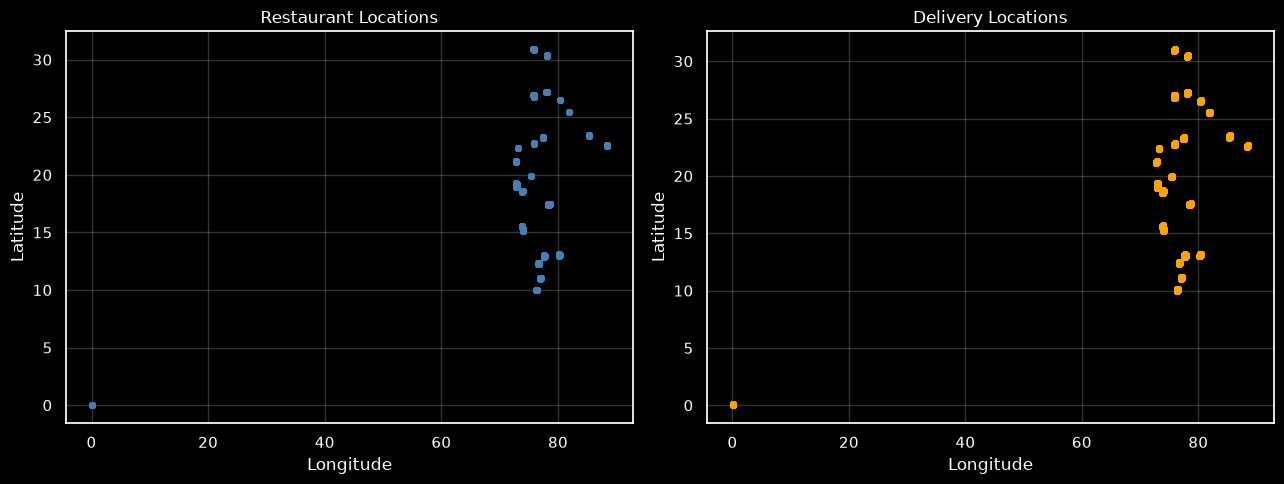

In [33]:
plt.style.use("dark_background")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
    facecolor="black"
)

# Restaurant locations
axes[0].scatter(
    coordinates["Restaurant_longitude"],
    coordinates["Restaurant_latitude"],
    color="steelblue",
    alpha=0.4,
    s=15
)

axes[0].set_title("Restaurant Locations")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].grid(alpha=0.2)

# Delivery locations
axes[1].scatter(
    coordinates["Delivery_location_longitude"],
    coordinates["Delivery_location_latitude"],
    color="orange",
    alpha=0.4,
    s=15
)

axes[1].set_title("Delivery Locations")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

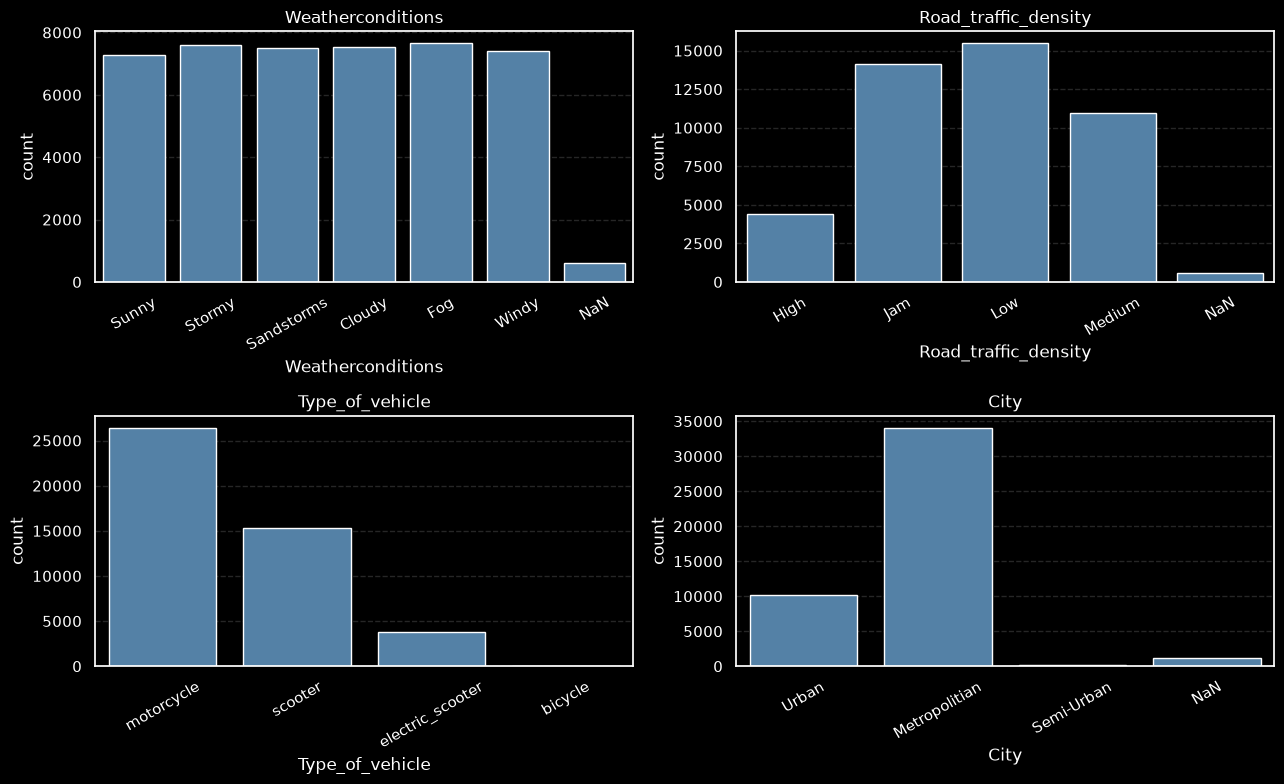

In [35]:
plt.style.use("dark_background")

categorical_columns = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_vehicle",
    "City",
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 8),
    facecolor="black"
)

for column, axis in zip(categorical_columns, axes.flat):
    values = (
        raw_dataframe[column]
        .astype("string")
        .str.strip()
    )

    if column == "Weatherconditions":
        values = (
            values
            .str.replace("conditions", "", regex=False)
            .str.strip()
        )

    sns.countplot(
        x=values,
        ax=axis,
        color="steelblue"
    )

    axis.set_title(column, color="white")
    axis.set_facecolor("black")
    axis.tick_params(
        axis="x",
        rotation=30,
        colors="white"
    )
    axis.tick_params(axis="y", colors="white")
    axis.grid(
        axis="y",
        color="gray",
        linestyle="--",
        alpha=0.3
    )

plt.tight_layout()
plt.show()

In [ ]:

delivery_time = pd.to_numeric(
    raw_dataframe["Time_taken(min)"]
        .astype("string")
        .str.extract(r"(\d+)")[0],
    errors="coerce"
).dropna()

# Detect outliers with IQR
q1 = delivery_time.quantile(0.25)
q3 = delivery_time.quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

outlier_count = (
    (delivery_time < lower_limit)
    | (delivery_time > upper_limit)
).sum()

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Potential outliers:", outlier_count)

Lower limit: -0.5
Upper limit: 51.5
Potential outliers: 270


### Outlier decision

Potential outliers are not automatically removed because long delivery times may represent real delays caused by traffic, weather or distance.

Only impossible delivery times less than or equal to zero are removed.

In [25]:
cleaned_dataframe = clean_data(raw_dataframe)

print("Before cleaning:", raw_dataframe.shape)
print("After cleaning:", cleaned_dataframe.shape)

display(cleaned_dataframe.head())

Before cleaning: (45593, 20)
After cleaning: (40353, 11)


,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_vehicle,City,Time_taken(min)
0,22.745049,75.892471,22.765049,75.912471,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,24.0
1,12.913041,77.683237,13.043041,77.813237,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,33.0
2,12.914264,77.678400,12.924264,77.688400,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,26.0
3,11.003669,76.976494,11.053669,77.026494,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,21.0
4,12.972793,80.249982,13.012793,80.289982,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,30.0


In [38]:
print("Remainig missing values:")
print(cleaned_dataframe.isna().sum())

print(
    "\n Remainig duplicates:",
    cleaned_dataframe.duplicated().sum()
)

print("\n Non positive delivery times:",
(
    cleaned_dataframe["Time_taken(min)"] <= 0
).sum()
)

cleaned_dataframe.info()

Remainig missing values:
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Type_of_vehicle                0
City                           0
Time_taken(min)                0
dtype: int64

 Remainig duplicates: 5

 Non positive delivery times: 0
<class 'pandas.DataFrame'>
RangeIndex: 40353 entries, 0 to 40352
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Restaurant_latitude          40353 non-null  float64
 1   Restaurant_longitude         40353 non-null  float64
 2   Delivery_location_latitude   40353 non-null  float64
 3   Delivery_location_longitude  40353 non-null  float64
 4   Time_Orderd                  40353 non-null  object 
 5   Time_Order_picked            403

In [39]:
removed_columns = sorted(
    set(raw_dataframe.columns)
    - set(cleaned_dataframe.columns)
)

print("Removed columns:")

for column in removed_columns:
    print(f"- {column}")

Removed columns:
- Delivery_person_Age
- Delivery_person_ID
- Delivery_person_Ratings
- Festival
- ID
- Order_Date
- Type_of_order
- Vehicle_condition
- multiple_deliveries


In [40]:
clean_data_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

cleaned_dataframe.to_csv(
    clean_data_path,
    index=False
)

print("DAtaset saved to: ", clean_data_path)

DAtaset saved to:  /home/bsar/Desktop/delivery-eta/data/processed/delivery_clean.csv


## Cleaning summary

- The dataset structure and data types were inspected.
- Spaces and parasite text were removed.
- Missing values and duplicates were checked.
- Invalid GPS locations and delivery times were treated.
- Realistic delivery-time outliers were retained.
- Missing categorical values were filled with the mode.
- Unhelpful columns were removed.
- The cleaned dataset was saved to `data/processed/delivery_clean.csv`.